## Goals: Training the GradientBoostingRegressor Model to set a baseline performance model

This notebook trains the model on the full *baseline_dataset* for the final prediction on evaluation data.

The model will be in charge to generalize across water stations in Brazil and France. 

> **Note:** This notebook requires outputs from the `00 Preprocessing` notebooks.

### 1. Data Import and Setup

This section imports the necessary libraries, sets up environment paths, and includes custom utility functions.

In [19]:
import os
import sys

import joblib
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.ensemble import GradientBoostingRegressor

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

from src.utils.model import split_dataset, compare_models_per_station

##### Constants :
- **INPUT_DIR**: Directory for input data (same as in "02 - Feature Engineering").
- **MODEL_DIR**: Directory where trained models are saved.
- **DATASET_DIR**: Directory where the Zenodo dataset is unzipped.

##### Model Parameters

- **SEED**: 42 (for reproducibility)
- **NUMBER_OF_WEEK**: 4 (one model is trained per week)

##### FINAL_MODELS

- **mapie**: Combines LightGBM with MAPIE. **MAPIE** (Model Agnostic Prediction Interval Estimator) computes prediction intervals for any regression model using conformal methods.
- **qrf**: Quantile Random Forest (natively produces prediction intervals)
- **ebm**: Explainable Boosting Machine is used as a exemple that does not natively implement prediction intervals, but that can be customised to do so.

In [ ]:
INPUT_DIR = "../../../data/input/"
MODEL_DIR = "../../../models/gbr"
DATASET_DIR = "../../../dataset/"

SEED = 42
NUMBER_OF_WEEK = 4 # Number of weeks to predict one model is trained per week
TIME_VALIDATION = "2000-01-01 00:00:00"


gbr = {}

COLUMNS_TO_DROP = ["water_flow_week1", "station_code", "water_flow_week2", "water_flow_week3", "water_flow_week4"]


TypeError: unhashable type: 'dict'

### 2. Data Loading
Load in the baseline datasets, create the directory to save models.

In [22]:
dataset_train = pd.read_csv(f"{INPUT_DIR}dataset_baseline.csv")

dataset_train = dataset_train.set_index("ObsDate")

if not os.path.exists(f"{MODEL_DIR}final/"):
    os.makedirs(f"{MODEL_DIR}final/")

Data pre-processing removal of unnecessary columns, setup of the target

In [23]:
X_train = dataset_train.drop(columns=COLUMNS_TO_DROP)
y_train = {}
for i in range(0, NUMBER_OF_WEEK):
    y_train[i] = dataset_train[f"water_flow_week{i+1}"]


### 2. Models training

In [27]:
train_gbr, val_gbr, val_temporal  = split_dataset(dataset_train, 0.75, TIME_VALIDATION)

X_train_gbr = train_gbr.drop(columns=COLUMNS_TO_DROP)
print(len(X_train_gbr.columns))

y_train_gbr = {}
for i in range(0, NUMBER_OF_WEEK):
    y_train_gbr[i] = train_gbr[f"water_flow_week{i+1}"]

X_val = val_gbr.drop(columns=COLUMNS_TO_DROP)
y_val = {}
y_val[0] = val_gbr["water_flow_week1"]
for i in range(1, NUMBER_OF_WEEK):
    y_val[i] = val_gbr[f"water_flow_week{i+1}"]

for i in range(NUMBER_OF_WEEK):

    print(f"Training week {i} median")
    gbr[i] = {}
    gbr[i]["median"] = GradientBoostingRegressor(loss="squared_error")
    gbr[i]["median"].fit(X_train_gbr, y_train_gbr[i])
    
    print(f"Training week {i} low")
    gbr[i]["low"] = GradientBoostingRegressor(loss="quantile", alpha=0.05)
    gbr[i]["low"].fit(X_train_gbr, y_train_gbr[i])

    print(f"Training week {i} high")
    gbr[i]["high"] = GradientBoostingRegressor(loss="quantile", alpha=0.95)
    gbr[i]["high"].fit(X_train_gbr, y_train_gbr[i])

    time = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")

    joblib.dump(gbr[i]["median"], f"{MODEL_DIR}final/svr_median_{time}_week_{i}.pkl")
    joblib.dump(gbr[i]["low"], f"{MODEL_DIR}final/svr_low_{time}_week_{i}.pkl")
    joblib.dump(gbr[i]["high"], f"{MODEL_DIR}final/svr_high_{time}_week_{i}.pkl")


154
Training week 0 median
Training week 0 low
Training week 0 high
Training week 1 median
Training week 1 low
Training week 1 high
Training week 2 median
Training week 2 low
Training week 2 high
Training week 3 median
Training week 3 low
Training week 3 high


### 3. Performance Evaluation on the Full Training Set

> **Note:**  
> The performance displayed here is calculated on the training set. This does not necessarily reflect the models' performance on unseen data.


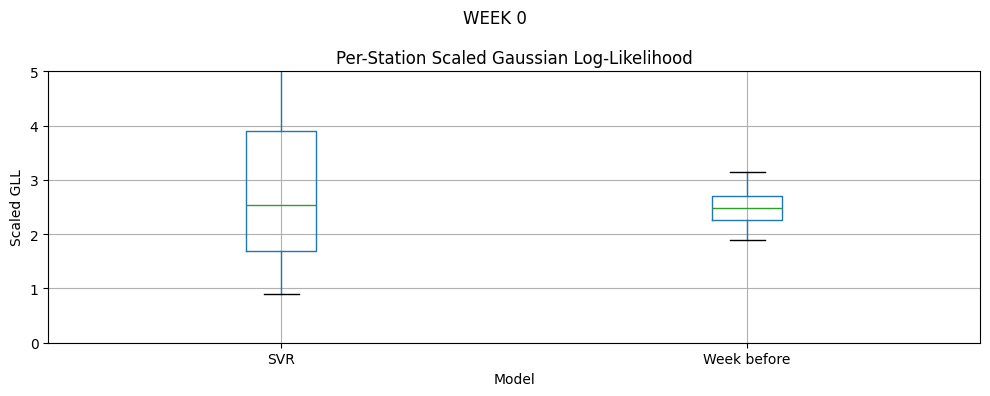

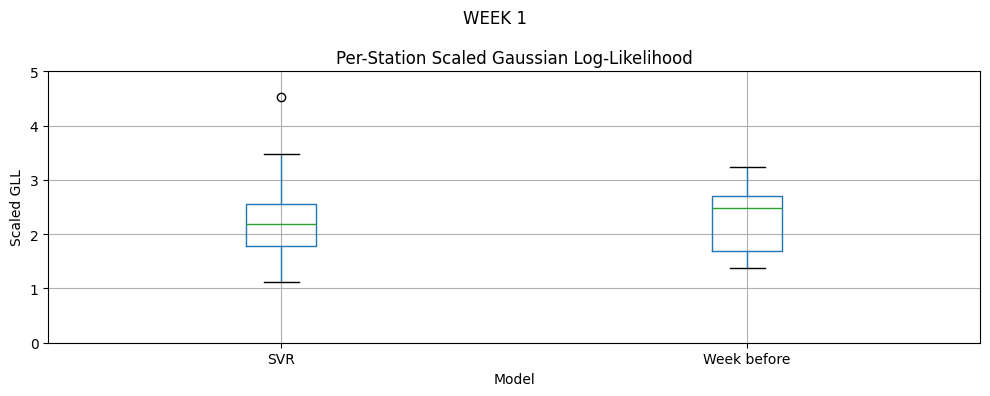

c:\Users\chapu\E.Lucas\Perso\Github\WaterScarcity.Hackathon\src\utils\model.py:169: RuntimeWarning: invalid value encountered in log
  np.log(sigma_s) + abs((y_true_s - y_pred_s)) / abs(2 * sigma_s)
c:\Users\chapu\E.Lucas\Perso\Github\WaterScarcity.Hackathon\src\utils\model.py:169: RuntimeWarning: invalid value encountered in log
  np.log(sigma_s) + abs((y_true_s - y_pred_s)) / abs(2 * sigma_s)
c:\Users\chapu\E.Lucas\Perso\Github\WaterScarcity.Hackathon\src\utils\model.py:169: RuntimeWarning: invalid value encountered in log
  np.log(sigma_s) + abs((y_true_s - y_pred_s)) / abs(2 * sigma_s)
c:\Users\chapu\E.Lucas\Perso\Github\WaterScarcity.Hackathon\src\utils\model.py:169: RuntimeWarning: invalid value encountered in log
  np.log(sigma_s) + abs((y_true_s - y_pred_s)) / abs(2 * sigma_s)
c:\Users\chapu\E.Lucas\Perso\Github\WaterScarcity.Hackathon\src\utils\model.py:169: RuntimeWarning: invalid value encountered in log
  np.log(sigma_s) + abs((y_true_s - y_pred_s)) / abs(2 * sigma_s)


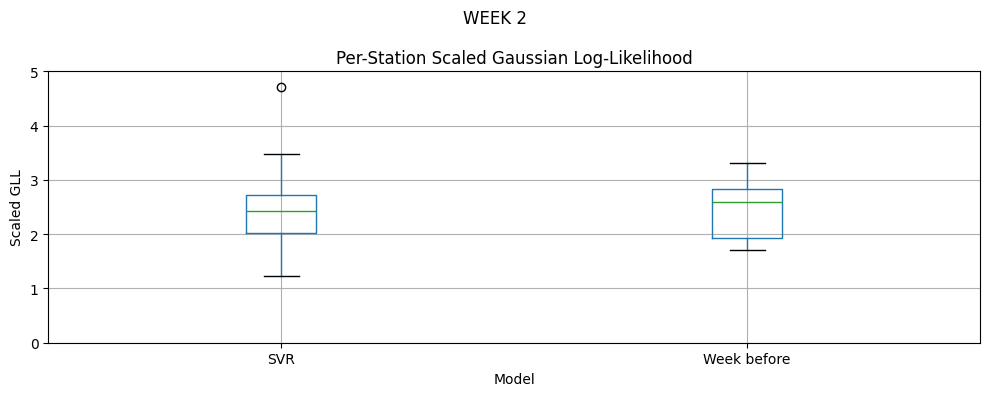

c:\Users\chapu\E.Lucas\Perso\Github\WaterScarcity.Hackathon\src\utils\model.py:169: RuntimeWarning: invalid value encountered in log
  np.log(sigma_s) + abs((y_true_s - y_pred_s)) / abs(2 * sigma_s)
c:\Users\chapu\E.Lucas\Perso\Github\WaterScarcity.Hackathon\src\utils\model.py:169: RuntimeWarning: invalid value encountered in log
  np.log(sigma_s) + abs((y_true_s - y_pred_s)) / abs(2 * sigma_s)
c:\Users\chapu\E.Lucas\Perso\Github\WaterScarcity.Hackathon\src\utils\model.py:169: RuntimeWarning: invalid value encountered in log
  np.log(sigma_s) + abs((y_true_s - y_pred_s)) / abs(2 * sigma_s)
c:\Users\chapu\E.Lucas\Perso\Github\WaterScarcity.Hackathon\src\utils\model.py:169: RuntimeWarning: invalid value encountered in log
  np.log(sigma_s) + abs((y_true_s - y_pred_s)) / abs(2 * sigma_s)


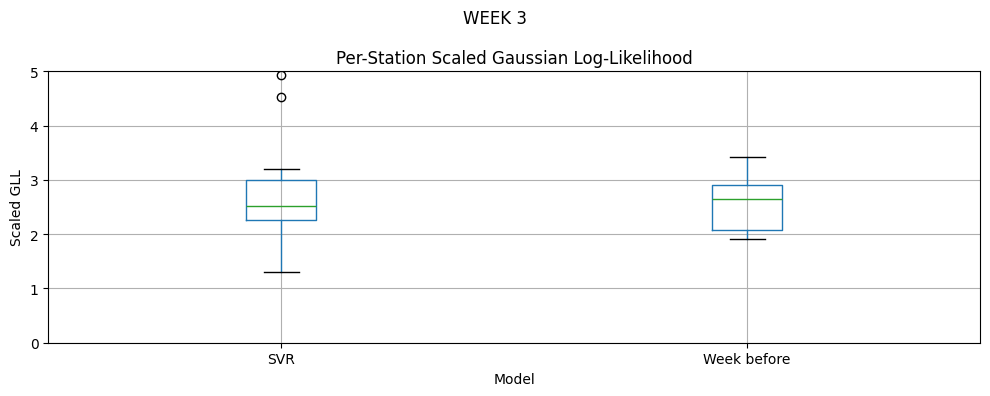

In [31]:
y_train_stations = dataset_train["station_code"].values

for i in range(NUMBER_OF_WEEK):
    predictions = []
    baseline_day_before = dataset_train["water_flow_lag_1w"]
    predictions.append({"model": "Week before", "prediction": baseline_day_before, "dataset":"train", "stations": y_train_stations, "prediction_interval": None})
    y_pred_gbr = gbr[i]["median"].predict(X_train)
    y_pis_gbr = np.stack([
        gbr[i]["low"].predict(X_train),
        gbr[i]["high"].predict(X_train)
    ], axis=1)
    predictions.append({"model": "SVR", "prediction": y_pred_gbr, "dataset":"train", "stations": y_train_stations, "prediction_interval": y_pis_gbr})
    compare_models_per_station(
        y_train[i].values,
        predictions,
        y_train_stations,
        column_to_display="log_likelihood" ,
        title = f"WEEK {i}")

### 4. Coverage on the Full Training Set

> **Note:**  
> The performance displayed here is calculated on the training set. This does not necessarily reflect the models' performance on unseen data.


In [33]:
for i in range(NUMBER_OF_WEEK):

    predictions = []
    baseline_day_before = dataset_train["water_flow_lag_1w"]
    predictions.append({"model": "Week before", "prediction": baseline_day_before, "dataset":"train", "stations": y_train_stations, "prediction_interval": None})
    
    y_pred_gbr = gbr[i]["median"].predict(X_train)
    y_pis_gbr = np.stack([
        gbr[i]["low"].predict(X_train),
        gbr[i]["high"].predict(X_train)
    ], axis=1)
    predictions.append({"model": "LGBM+MAPIE", "prediction": y_pred_gbr, "dataset":"train", "stations": y_train_stations, "prediction_interval": y_pis_gbr})
    coverage = (y_train[i].values >= y_pis_gbr[:, 0]) & (y_train[i].values <= y_pis_gbr[:, 1])
    print(f"MAPIE coverage of the prediction interval for week {i}: {coverage.mean()}")


MAPIE coverage of the prediction interval for week 0: 0.8741162815236889
MAPIE coverage of the prediction interval for week 1: 0.8824874256973022
MAPIE coverage of the prediction interval for week 2: 0.860856107769688
MAPIE coverage of the prediction interval for week 3: 0.8642327037388766
